In [233]:
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.propagation import focus_fixed_sampling, unfocus_fixed_sampling
from prysm.geometry import circle
from prysm.x.dm import DM

from poi.influence_funcs import gaussian_influence_function
from poi.modes import fourier_modes_sequence

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

In [234]:
# First we need a forward model of the system
# NOTE: Influence functions should peak at 1

# Basic inputs to a prysm DM
# - influence function
# - number of actuators in X and Y axes
# - separation of the actuators in the array containing the lattice, in units of samples

nact = 22
act_pitch = 3
samples_per_act = 21
sampling_pitch = act_pitch / samples_per_act

x, y = make_xy_grid(512, dx=sampling_pitch)
r, th = cart_to_polar(x, y)
influence_func = gaussian_influence_function(r, act_pitch)#np.sinc(x/act_pitch) * np.sinc(y/act_pitch)
# influence_func /= np.max(influence_func)
Nout = x.shape[0]
dm = DM(influence_func, Nout, nact, samples_per_act, rot=(0,0,0), shift=(0, 0))

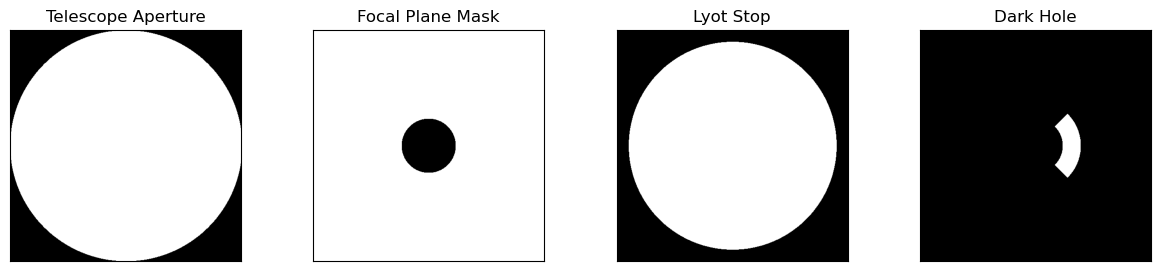

In [235]:
Npup = 512
x, y = make_xy_grid(Npup, diameter=2)
r, t = cart_to_polar(x, y)
A = circle(1, r)
LS = circle(0.9, r)

# create pupil function and propagate
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1/2 # microns
wvfnt = A * np.exp(1j * 2 * np.pi / WVL) # with error

# Sample field
focal = focus_fixed_sampling(wvfnt,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

# create a dark hole
um_to_LD = 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
u, v = make_xy_grid(focal.shape, dx=dx_img * um_to_LD)
rho, psi = cart_to_polar(u, v)

dark_hole = np.zeros_like(u)
IWA = 3
OWA = 5
CORO_IWA = 3
dark_hole[rho < OWA] = 1
dark_hole[rho < IWA] = 0
dark_hole[psi < -np.pi / 4] = 0
dark_hole[psi > np.pi / 4] = 0

FPM = np.ones_like(u)
FPM[ rho < CORO_IWA] = 0

focal_intensity = np.abs(focal)**2

plt.figure(figsize=[15,3])
plt.subplot(141)
plt.imshow(A, cmap='gray')
plt.xticks([],[])
plt.yticks([],[])
plt.title('Telescope Aperture')
plt.subplot(142)
plt.imshow(FPM, cmap='gray')
plt.title('Focal Plane Mask')
plt.xticks([],[])
plt.yticks([],[])
plt.subplot(143)
plt.imshow(LS, cmap='gray')
plt.title('Lyot Stop')
plt.xticks([],[])
plt.yticks([],[])
plt.subplot(144)
plt.imshow(dark_hole, cmap='gray')
plt.title('Dark Hole')
plt.xticks([],[])
plt.yticks([],[])
plt.show()

In [236]:
def snap_image(pupil_wfe=np.zeros_like(A), include_fpm=True):
    """take intensity image given a pupil wfe in microns

    Parameters
    ----------
    pupil_wfe : ndarray, optional
        wavefront error in microns, by default np.ones_like(A)
    """

    # create nominal wavefront
    wfe = np.exp(1j * 2 * np.pi / WVL * pupil_wfe)
    wvfnt_to_prop = wfe * wvfnt

    # propagate to focus
    focal = focus_fixed_sampling(wvfnt_to_prop,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    if include_fpm:
        focal *= FPM

    lyot = unfocus_fixed_sampling(focal,
                                input_dx=dx_img, # um
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=Dpup / wvfnt.shape[0], # mm
                                output_samples=wvfnt.shape[0])
    
    lyot *= LS

    coro = focus_fixed_sampling(lyot,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    return np.abs(coro)**2


In [237]:
sin_modes = fourier_modes_sequence(
    Nact=22,
    Nimg=Npup,
    psf_pixelscale_lamD=dx_img * um_to_LD,
    iwa=3,
    owa=5,
    which="sin",
    edge=3,
    fourier_sampling=1
)

cos_modes = fourier_modes_sequence(
    Nact=22,
    Nimg=Npup,
    psf_pixelscale_lamD=dx_img * um_to_LD,
    iwa=3,
    owa=5,
    which="cos",
    edge=3,
    fourier_sampling=1
)

sin_probe = np.sum(sin_modes, axis=0)
sin_probe /= sin_probe.max()

cos_probe = np.sum(cos_modes, axis=0)
cos_probe /= cos_probe.max()

In [238]:
diff_imgs = []
dm_surfs = []
for probe in [sin_probe, cos_probe]:
    dm.actuators[:] = probe
    img1 = snap_image(dm.render(wfe=True))
    img2 = snap_image(-dm.render(wfe=True))
    diff_imgs.append(img1-img2)
    dm_surfs.append(dm.render())

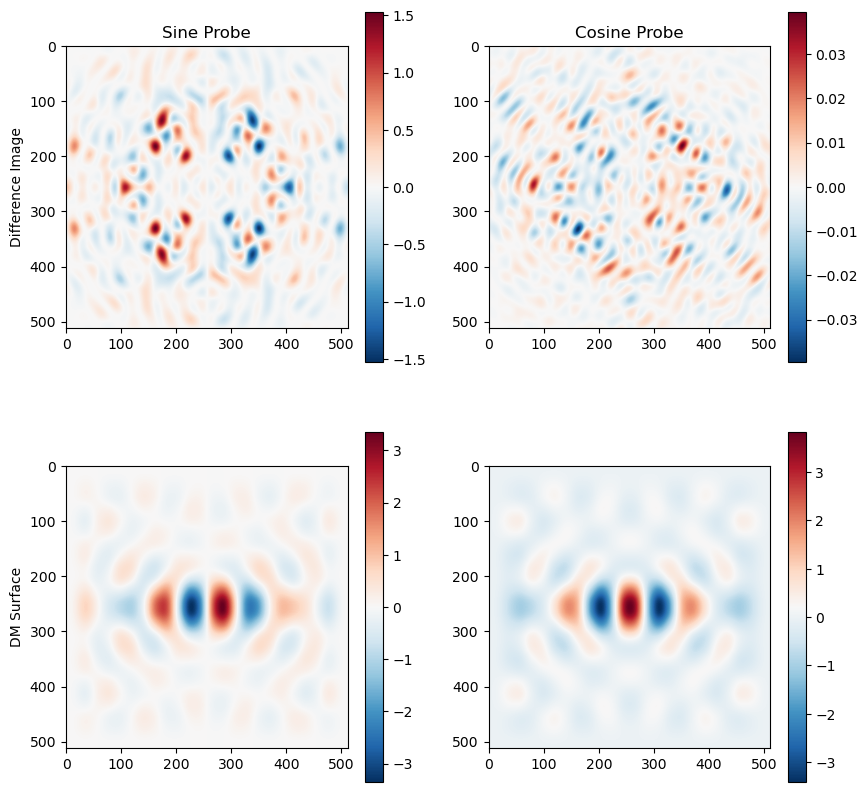

In [239]:
ref_contrast = snap_image(include_fpm=False).max()
plt.figure(figsize=[10,10])
plt.subplot(221)
plt.title("Sine Probe")
plt.imshow(diff_imgs[0] / 2, cmap="RdBu_r")
plt.colorbar()
plt.ylabel("Difference Image")
plt.subplot(222)
plt.title("Cosine Probe")
plt.imshow(diff_imgs[1] / 2, cmap="RdBu_r")
plt.colorbar()

plt.subplot(223)
plt.imshow(dm_surfs[0], cmap="RdBu_r")
plt.colorbar()
plt.ylabel("DM Surface")
plt.subplot(224)
plt.imshow(dm_surfs[1], cmap="RdBu_r")
plt.colorbar()
plt.show()

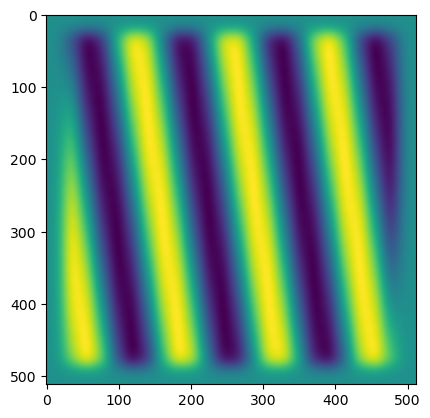

In [262]:
# put a sinusoid on the DM
aberration = sin_modes[8]
aberration /= aberration.max()
aberration /= 100
dm.actuators[:] = aberration
plt.imshow(dm.render())

In [263]:
# compute the delta images
I0 = snap_image(dm.render(wfe=True))
probe_images = []
for probe in [-sin_probe, sin_probe, -cos_probe, cos_probe]:

    dm.actuators[:] += probe
    img = snap_image(dm.render(wfe=True))
    dm.actuators[:] -= probe
    probe_images.append(img)

# Unpack
Im1 = probe_images[0]  # plus sin probe
Ip1 = probe_images[1]  # plus sin probe
Im2 = probe_images[2]  # plus sin probe
Ip2 = probe_images[3]  # plus sin probe

# Compute the relevant quantities
dI1 = Ip1 - Im1
dI2 = Ip2 - Im2

dE1 = dI1 / 4
dE2 = dI2 / 4

p = dI1 / (2 * (Ip1 + Im1 - 2 * I0))
q = dI2 / (2 * (Ip2 + Im2 - 2 * I0) )

In [264]:
E0 = p * dE1 + q * dE2

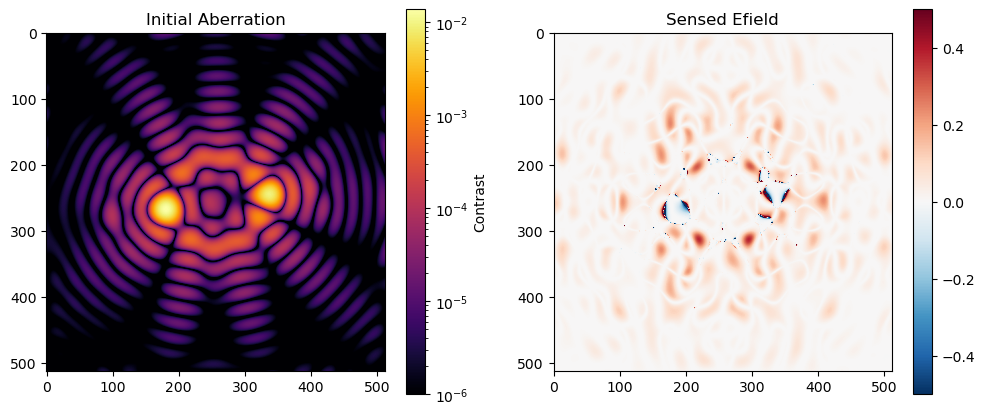

In [265]:
ref_contrast = snap_image(include_fpm=False).max()
vlim = 0.5
plt.figure(figsize=[12, 5])
plt.subplot(121)
plt.title("Initial Aberration")
plt.imshow(I0 / ref_contrast, cmap="inferno", norm=LogNorm(vmin=1e-6))
plt.colorbar(label="Contrast")
plt.subplot(122)
plt.title("Sensed Efield")
plt.imshow(E0, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.show()

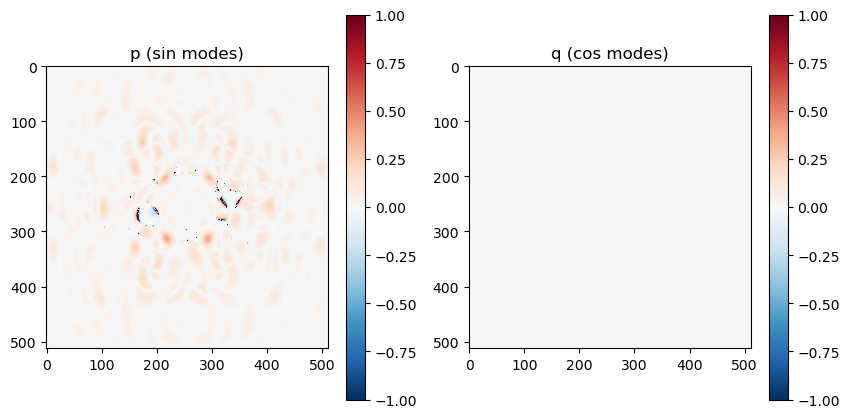

In [274]:
vlim = 1
plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("p (sin modes)")
plt.imshow(p*dE1, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()

plt.subplot(122)
plt.title("q (cos modes)")
plt.imshow(q*dE2, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.show()

In [267]:
# apply the correction

# Applying the correction
The correction is supposed to be the following:

$$V(\xi, \eta) = -\sum [p \circ sin(x\xi_i + y\eta_i) + q \circ cos(x\xi_i + y\eta_i)]$$

But the dimensions of p and q and the frequency domain are incompatible. Maybe there's a fitting step that's required to downsample p + q?

I think actually we need to ravel the components of P and Q that correspond to the fourier components within the dark hole, so it's time to operate on everything as a vector